## Notebook: Tratamento da base CadÚnico

**id_rastreabilidade:** RTB_002  
**Versão:** v01  
**Data de criação:** 25/03/2026  
**Última atualização:** 22/04/2026  
**Responsável:** Ailton Vendramini  

---

## 🎯 Finalidade
Realizar a leitura, validação estrutural e tratamento técnico da base bruta do CadÚnico, preparando os dados para a camada limpa do projeto IVS-H.

---

## 📥 Fonte de Dados
**Fonte:** CadÚnico  
**Camada de entrada:** `01_bruto`  
**Camada de saída:** `02_limpo`  
**Período de referência da execução:** `2025_12`  
**Período de comparação:** —  
**Tipo de recorte temporal:** corte transversal  

**Arquivo de entrada:**  
`C:\Users\ailto\Atlas-Social-de-Hortolandia\dados\cadunico\01_bruto\2025_12\cadunico.csv`

**Arquivo de saída previsto:**  
`C:\Users\ailto\Atlas-Social-de-Hortolandia\dados\cadunico\02_limpo\2025_12\cadunico_limpo.csv`

---

## 🧱 Base Conceitual
Documentos de apoio conceitual e metodológico do projeto:

- `docs/metodologia_ivsh.md`
- `docs/regras_negocio.md`
- `docs/padrao_nomenclatura.md`

---

## ⚙️ Escopo técnico deste notebook

**Este notebook deve:**
- carregar a base bruta do CadÚnico;
- verificar estrutura, colunas e tipos;
- identificar valores nulos e inconsistências iniciais;
- padronizar nomes de colunas, quando necessário;
- preparar a saída para a camada `02_limpo`.

**Este notebook não deve:**
- calcular o IVS-H final;
- misturar dados de outras fontes;
- alterar diretamente arquivos da camada `01_bruto`.

---

## 📊 Outputs esperados

| tipo_output | descrição | destino |
|---|---|---|
| exploratorio | validação inicial da base | não salvar |
| analitico | diagnósticos intermediários | `outputs/tabelas/cadunico/` |
| operacional | base limpa para próxima etapa | `dados/cadunico/02_limpo/2025_12/` |

---

## 🧠 Observações
- O arquivo bruto deve permanecer imutável.
- O período de referência deve ser explicitado também na primeira célula de código.
- Alterações estruturais relevantes devem ser registradas em nota técnica futura.

## pd.read_csv(...)

Parâmetros importantes:

sep=';' → CadÚnico usa ponto e vírgula
encoding='latin1' → evita erro com acentos
low_memory=False → evita warning e leitura inconsistente

## low_memory=False, dizemos ao Pandas:

“Leia tudo de uma vez e depois decida os tipos”

Resultado:

✔ leitura mais estável
✔ menos conflitos de tipo
✔ comportamento mais previsíve

## Quando usamos os

Usamos "os" quando queremos lidar com o sistema de arquivos, por exemplo:

listar pastas (os.listdir)
verificar se caminho existe (os.path.exists)
criar diretórios (os.makedirs)

## Tradução direta

os = gerenciar pastas e arquivos
pandas = ler e manipular dados

Regra prática

Se já sabemos o caminho e só quer ler → não precisa de os

In [1]:
import pandas as pd

# caminho do arquivo bruto
caminho = "../../dados/cadunico/01_bruto/2025_12/cadunico.csv"

# leitura da base
df = pd.read_csv(caminho, sep=';', encoding='latin1', low_memory=False)

In [2]:
df.shape          # df.shape é um atributo e sempre retorna um valor. Não é uma função

(72424, 211)

## Tradução simples
Forma	Significado
()	executar função
[]	acessar posição

## Deixando o resultado mais agradável

In [3]:
print ("linhas", df.shape[0])
print ("colunas",df.shape[1])
df.head()

linhas 72424
colunas 211


,d.cd_ibge,d.cod_familiar_fam,d.dat_cadastramento_fam,d.dat_atual_fam,d.cod_est_cadastral_fam,d.cod_forma_coleta_fam,d.dta_entrevista_fam,d.nom_localidade_fam,d.nom_tip_logradouro_fam,d.nom_titulo_logradouro_fam,...,p.ind_dinh_carregador_memb,p.ind_dinh_catador_memb,p.ind_dinh_servs_gerais_memb,p.ind_dinh_pede_memb,p.ind_dinh_vendas_memb,p.ind_dinh_outro_memb,p.ind_dinh_nao_resp_memb,p.ind_atend_nenhum_memb,p.ref_cad,p.ref_pbf
0,3519071,8477396,17/12/2001,04/08/2025,3,1,04/08/2025,JARDIM MINDA,RUA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/12/2025,202601.0
1,3519071,8477396,17/12/2001,04/08/2025,3,1,04/08/2025,JARDIM MINDA,RUA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/12/2025,202601.0
2,3519071,8477396,17/12/2001,04/08/2025,3,1,04/08/2025,JARDIM MINDA,RUA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/12/2025,202601.0
3,3519071,8477396,17/12/2001,04/08/2025,3,1,04/08/2025,JARDIM MINDA,RUA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/12/2025,202601.0
4,3519071,37372840,07/02/2002,14/04/2025,3,1,14/04/2025,JARDIM MONTE SINAI,RUA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/12/2025,202601.0


In [4]:
df.columns
df.dtypes

d.cd_ibge                      int64
 d.cod_familiar_fam            int64
 d.dat_cadastramento_fam      object
 d.dat_atual_fam              object
 d.cod_est_cadastral_fam       int64
                              ...   
 p.ind_dinh_outro_memb       float64
 p.ind_dinh_nao_resp_memb    float64
 p.ind_atend_nenhum_memb     float64
 p.ref_cad                    object
 p.ref_pbf                   float64
Length: 211, dtype: object

In [5]:
df.columns

Index(['d.cd_ibge', ' d.cod_familiar_fam', ' d.dat_cadastramento_fam',
       ' d.dat_atual_fam', ' d.cod_est_cadastral_fam',
       ' d.cod_forma_coleta_fam', ' d.dta_entrevista_fam',
       ' d.nom_localidade_fam', ' d.nom_tip_logradouro_fam',
       ' d.nom_titulo_logradouro_fam',
       ...
       ' p.ind_dinh_carregador_memb', ' p.ind_dinh_catador_memb',
       ' p.ind_dinh_servs_gerais_memb', ' p.ind_dinh_pede_memb',
       ' p.ind_dinh_vendas_memb', ' p.ind_dinh_outro_memb',
       ' p.ind_dinh_nao_resp_memb', ' p.ind_atend_nenhum_memb', ' p.ref_cad',
       ' p.ref_pbf'],
      dtype='object', length=211)

In [6]:
list(df.columns)

['d.cd_ibge',
 ' d.cod_familiar_fam',
 ' d.dat_cadastramento_fam',
 ' d.dat_atual_fam',
 ' d.cod_est_cadastral_fam',
 ' d.cod_forma_coleta_fam',
 ' d.dta_entrevista_fam',
 ' d.nom_localidade_fam',
 ' d.nom_tip_logradouro_fam',
 ' d.nom_titulo_logradouro_fam',
 ' d.nom_logradouro_fam',
 ' d.num_logradouro_fam',
 ' d.des_complemento_fam',
 ' d.des_complemento_adic_fam',
 ' d.num_cep_logradouro_fam',
 ' d.cod_unidade_territorial_fam',
 ' d.nom_unidade_territorial_fam',
 ' d.txt_referencia_local_fam',
 ' d.nom_entrevistador_fam',
 ' d.num_cpf_entrevistador_fam',
 ' d.vlr_renda_media_fam',
 ' d.fx_rfpc',
 ' d.vlr_renda_total_fam',
 ' d.marc_pbf',
 ' d.qtde_meses_desat_cat',
 ' d.cod_local_domic_fam',
 ' d.cod_especie_domic_fam',
 ' d.qtd_comodos_domic_fam',
 ' d.qtd_comodos_dormitorio_fam',
 ' d.cod_material_piso_fam',
 ' d.cod_material_domic_fam',
 ' d.cod_agua_canalizada_fam',
 ' d.cod_abaste_agua_domic_fam',
 ' d.cod_banheiro_domic_fam',
 ' d.cod_escoa_sanitario_domic_fam',
 ' d.cod_dest

In [7]:
colunas_renda = []

for col in df.columns:
    if 'renda' in col:
        colunas_renda.append(col)

colunas_renda


[' d.vlr_renda_media_fam',
 ' d.vlr_renda_total_fam',
 ' p.fx_renda_individual_805',
 ' p.fx_renda_individual_808',
 ' p.fx_renda_individual_809_1',
 ' p.fx_renda_individual_809_2',
 ' p.fx_renda_individual_809_3',
 ' p.fx_renda_individual_809_4',
 ' p.fx_renda_individual_809_5']

In [8]:
colunas_valor = []

for col in df.columns:
    if "vlr" in col:
        colunas_valor.append(col)

colunas_valor

[' d.vlr_renda_media_fam', ' d.vlr_renda_total_fam']

In [9]:
df[[' d.vlr_renda_media_fam', ' d.vlr_renda_total_fam']].describe().round(2)

,d.vlr_renda_media_fam,d.vlr_renda_total_fam
count,72424.00,72424.00
mean,701.29,1851.17
std,807.53,2129.80
min,0.00,0.00
25%,67.00,200.00
50%,467.00,1512.00
75%,1100.25,2784.00
max,12779.00,25558.00


In [10]:
for col in df.columns:
    print(f"'{col}'")

'd.cd_ibge'
' d.cod_familiar_fam'
' d.dat_cadastramento_fam'
' d.dat_atual_fam'
' d.cod_est_cadastral_fam'
' d.cod_forma_coleta_fam'
' d.dta_entrevista_fam'
' d.nom_localidade_fam'
' d.nom_tip_logradouro_fam'
' d.nom_titulo_logradouro_fam'
' d.nom_logradouro_fam'
' d.num_logradouro_fam'
' d.des_complemento_fam'
' d.des_complemento_adic_fam'
' d.num_cep_logradouro_fam'
' d.cod_unidade_territorial_fam'
' d.nom_unidade_territorial_fam'
' d.txt_referencia_local_fam'
' d.nom_entrevistador_fam'
' d.num_cpf_entrevistador_fam'
' d.vlr_renda_media_fam'
' d.fx_rfpc'
' d.vlr_renda_total_fam'
' d.marc_pbf'
' d.qtde_meses_desat_cat'
' d.cod_local_domic_fam'
' d.cod_especie_domic_fam'
' d.qtd_comodos_domic_fam'
' d.qtd_comodos_dormitorio_fam'
' d.cod_material_piso_fam'
' d.cod_material_domic_fam'
' d.cod_agua_canalizada_fam'
' d.cod_abaste_agua_domic_fam'
' d.cod_banheiro_domic_fam'
' d.cod_escoa_sanitario_domic_fam'
' d.cod_destino_lixo_domic_fam'
' d.cod_iluminacao_domic_fam'
' d.cod_calcamento_do

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df[['d.vlr_renda_media_fam']].sort_values(by='d.vlr_renda_media_fam', ascending=False).head(10)

,d.vlr_renda_media_fam
53503,12779
53504,12779
55337,12110
50537,10862
53308,10792
53309,10792
70580,9782
57850,9615
44976,9251
52764,9226


In [13]:
df[['d.cod_familiar_fam', 'd.vlr_renda_media_fam']]\
    .sort_values(by='d.vlr_renda_media_fam', ascending=False)\
    .head(10)

,d.cod_familiar_fam,d.vlr_renda_media_fam
53503,7964057197,12779
53504,7964057197,12779
55337,8063067185,12110
50537,7792699420,10862
53308,7952118803,10792
53309,7952118803,10792
70580,20209127597,9782
57850,8199795972,9615
44976,7301262264,9251
52764,7929943020,9226


In [14]:
df[['d.cod_familiar_fam', 'd.vlr_renda_media_fam', 'd.dta_entrevista_fam', 'p.num_cpf_pessoa']]\
    .sort_values(by='d.dta_entrevista_fam', ascending=True)\
    .head(10)

,d.cod_familiar_fam,d.vlr_renda_media_fam,d.dta_entrevista_fam,p.num_cpf_pessoa
39195,6843786200,1543,01/02/2022,1.719702e+10
39180,6842655595,852,01/02/2022,2.222226e+10
39181,6842655595,852,01/02/2022,5.638419e+10
39185,6843121829,1518,01/02/2022,2.579221e+10
39194,6843786200,1543,01/02/2022,4.906720e+10
39196,6843786200,1543,01/02/2022,4.681696e+10
39218,6844601301,1016,01/02/2022,4.577266e+10
39197,6843786200,1543,01/02/2022,5.743973e+10
39210,6844099924,1130,01/02/2022,1.727036e+10
39211,6844099924,1130,01/02/2022,1.549336e+10


In [15]:
pessoas_por_familia = (
    df.groupby('d.cod_familiar_fam')
      .size()
      .reset_index(name='qtd_pessoas_familia')
)

pessoas_por_familia.head(20)

,d.cod_familiar_fam,qtd_pessoas_familia
0,8477396,4
1,37372840,2
2,46512861,4
3,47959118,3
4,55477330,4
5,66761549,4
6,92741118,2
7,95573690,2
8,109502302,2
9,117008400,3


In [16]:
familias = (
    df.groupby('d.cod_familiar_fam')
      .agg({
          'd.vlr_renda_media_fam': 'first',
          'd.vlr_renda_total_fam': 'first',
          'd.dta_entrevista_fam': 'first',
          'p.num_cpf_pessoa': 'count'
      })
      .reset_index()
)

familias = familias.rename(columns={
    'p.num_cpf_pessoa': 'qtd_pessoas_familia'
})

familias.head(10)

,d.cod_familiar_fam,d.vlr_renda_media_fam,d.vlr_renda_total_fam,d.dta_entrevista_fam,qtd_pessoas_familia
0,8477396,379,1516,04/08/2025,4
1,37372840,0,0,14/04/2025,2
2,46512861,191,764,16/06/2025,4
3,47959118,0,0,06/09/2024,2
4,55477330,148,592,15/04/2025,4
5,66761549,41,164,24/02/2025,4
6,92741118,1518,3036,02/10/2025,2
7,95573690,0,0,06/06/2024,2
8,109502302,0,0,26/11/2025,2
9,117008400,346,1038,10/05/2024,3


In [17]:
familias.sort_values(by='qtd_pessoas_familia', ascending=False).head(30)

,d.cod_familiar_fam,d.vlr_renda_media_fam,d.vlr_renda_total_fam,d.dta_entrevista_fam,qtd_pessoas_familia
20874,7882031429,281,3091,22/04/2024,11
3137,3417039150,434,4340,14/03/2024,10
21838,7998260220,275,2475,27/05/2024,9
21887,8005029730,544,4896,31/05/2023,9
13278,6424010556,111,999,09/05/2025,9
2105,2596033682,41,369,08/04/2025,9
7054,4881128345,1164,10476,03/11/2022,9
7375,4959754001,320,2880,30/09/2024,9
25733,8482618016,0,0,06/11/2024,9
1385,2093045966,0,0,01/04/2024,8


In [18]:
familias['renda_per_capita'] = (
    familias['d.vlr_renda_total_fam'] / familias['qtd_pessoas_familia']
)

In [19]:
familias[['renda_per_capita']].describe().round(2)

,renda_per_capita
count,30357.0
mean,inf
std,NaN
min,0.0
25%,62.0
50%,568.0
75%,1465.0
max,inf


## Sobre count e size

Aqui há um detalhe fino — e importante.

count

Conta valores não nulos em uma coluna.

size

Conta linhas do grupo, independentemente de nulo.

## O que faz cada comando

1. 

groupby = agrupar linhas com algo em comum, esse comando junta linhas e não junta colunas

2.

agg = dizer o que fazer com cada coluna dentro do grupo

3.

size = contar linhas
count = contar valores preenchidos

4.

👉 'first' pega apenas um valor por grupo.
## Jupyter

Melhor para:

explorar dados
testar ideias
ver resultados rapidamente
aprender
## VS Code

Melhor para:

organizar projeto
versionar código
criar scripts mais “definitivos”
integrar com Git

In [20]:
# Agrupar por família
# Cada grupo reúne todas as pessoas da mesma família

df.groupby('d.cod_familiar_fam')

In [21]:
# Contar quantas linhas existem em cada família
# Como 1 linha = 1 pessoa, isso vira quantidade de pessoas por família

df.groupby('d.cod_familiar_fam').size()

d.cod_familiar_fam
8477396        4
37372840       2
46512861       4
47959118       3
55477330       4
              ..
20335488137    1
20335506216    2
20335587542    1
20335593518    1
20335767109    2
Length: 30362, dtype: int64

In [22]:
# Aplicar operações diferentes para colunas diferentes
# Exemplo: pegar a primeira renda da família e contar quantas pessoas há

df.groupby('d.cod_familiar_fam').agg({
    'd.vlr_renda_total_fam': 'first',
    'p.num_cpf_pessoa': 'count'
})

,d.vlr_renda_total_fam,p.num_cpf_pessoa
d.cod_familiar_fam,,
8477396,1516,4
37372840,0,2
46512861,764,4
47959118,0,2
55477330,592,4
...,...,...
20335488137,1518,1
20335506216,0,2
20335587542,1332,1


In [23]:
df.groupby('d.cod_familiar_fam').size().describe().round(2)

count    30362.00
mean         2.39
std          1.21
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         11.00
dtype: float64

In [24]:
len(df)

72424

In [25]:
df.shape

(72424, 211)

In [26]:
df.shape[0]

72424

In [27]:
df.groupby('d.cod_familiar_fam').size().sum()

72424

In [28]:
df.groupby('d.cod_familiar_fam').size().value_counts()

2     10609
1      7783
3      6739
4      3585
5      1184
6       335
7        93
8        24
9         8
10        1
11        1
Name: count, dtype: int64

🔹 Etapa 1 — groupby(...)
df.groupby('d.cod_familiar_fam')

👉 Agrupa as pessoas por família

🔹 Etapa 2 — .size()
df.groupby('d.cod_familiar_fam').size()

👉 Conta quantas pessoas existem em cada família

Resultado (exemplo):

Família A → 2 pessoas  
Família B → 4 pessoas  
Família C → 1 pessoa  
Família D → 2 pessoas
🔹 Etapa 3 — .value_counts()
...size().value_counts()

👉 Agora ele faz outra pergunta:

“Quantas famílias têm 1 pessoa? Quantas têm 2? Quantas têm 3?”

🎯 Resultado final (o seu caso)
2 → 10609 famílias  
1 → 7783 famílias  
3 → 6739 famílias  
4 → 3585 famílias  
...
🧠 Tradução humana

👉 Esse comando está dizendo:

“Qual é a distribuição do tamanho das famílias”

In [29]:
distribuicao = (
    df.groupby('d.cod_familiar_fam')
      .size()
      .value_counts()
      .reset_index()
)

distribuicao.columns = ['qtd_pessoas_familia', 'qtd_familias']

distribuicao

,qtd_pessoas_familia,qtd_familias
0,2,10609
1,1,7783
2,3,6739
3,4,3585
4,5,1184
5,6,335
6,7,93
7,8,24
8,9,8
9,10,1


In [30]:
# Agrupar por família e contar quantas pessoas há em cada uma
distribuicao = (
    df.groupby('d.cod_familiar_fam')
      .size()
      .value_counts()
      .reset_index()
)

# Renomear colunas para algo legível
distribuicao.columns = ['qtd_pessoas_familia', 'qtd_familias']

# Calcular o total de famílias
total_familias = distribuicao['qtd_familias'].sum()

# Adicionar coluna com o total (mesmo valor em todas as linhas)
distribuicao['total_familias'] = total_familias

# Criar coluna de percentual
distribuicao['percentual'] = (
    distribuicao['qtd_familias'] / total_familias
) * 100

# Arredondar para 2 casas decimais
distribuicao['percentual'] = distribuicao['percentual'].round(2)

# Ordenar pela quantidade de famílias
distribuicao = distribuicao.sort_values(by='qtd_familias', ascending=False)

# Mostrar resultado
distribuicao

,qtd_pessoas_familia,qtd_familias,total_familias,percentual
0,2,10609,30362,34.94
1,1,7783,30362,25.63
2,3,6739,30362,22.20
3,4,3585,30362,11.81
4,5,1184,30362,3.90
5,6,335,30362,1.10
6,7,93,30362,0.31
7,8,24,30362,0.08
8,9,8,30362,0.03
9,10,1,30362,0.00


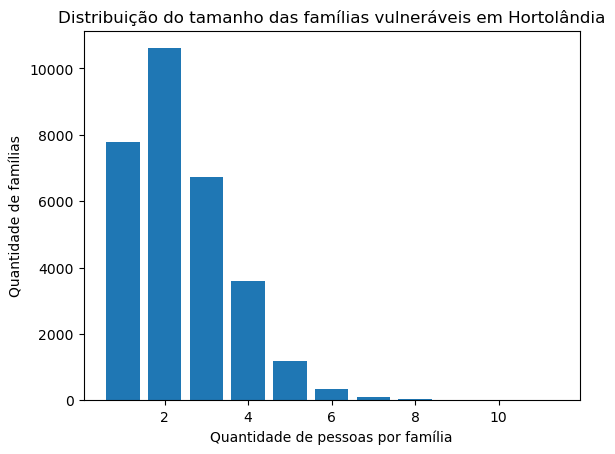

In [31]:
import matplotlib.pyplot as plt

# Criar o histograma
plt.figure()

plt.bar(
    distribuicao['qtd_pessoas_familia'],
    distribuicao['qtd_familias']
)

# Títulos e rótulos
plt.title('Distribuição do tamanho das famílias vulneráveis em Hortolândia')
plt.xlabel('Quantidade de pessoas por família')
plt.ylabel('Quantidade de famílias')

# Mostrar gráfico
plt.show()

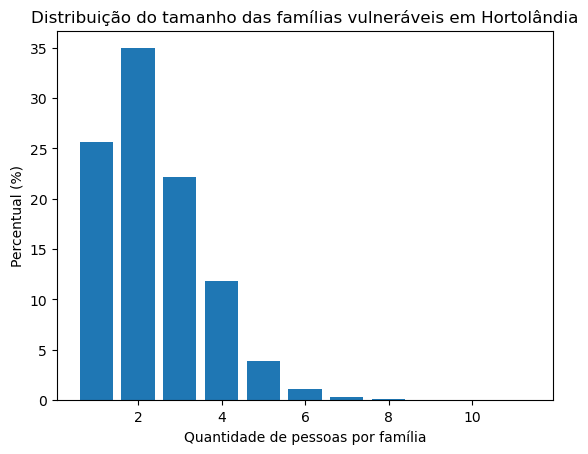

In [32]:
plt.figure()

plt.bar(
    distribuicao['qtd_pessoas_familia'],
    distribuicao['percentual']
)

plt.title('Distribuição do tamanho das famílias vulneráveis em Hortolândia')
plt.xlabel('Quantidade de pessoas por família')
plt.ylabel('Percentual (%)')

plt.show()

In [33]:
renda_por_tamanho = (
    familias.groupby('qtd_pessoas_familia')
             ['renda_per_capita']
             .mean()
             .reset_index()
              .round(2)
)

renda_por_tamanho

,qtd_pessoas_familia,renda_per_capita
0,0,inf
1,1,1112.16
2,2,857.16
3,3,600.50
4,4,558.31
5,5,493.53
6,6,366.97
7,7,343.71
8,8,258.59
9,9,350.71


In [34]:
pessoas_por_familia = (
    df.groupby('d.cod_familiar_fam')
      .size()
      .reset_index(name='qtd_pessoas_familia')
)

distribuicao = (
    pessoas_por_familia['qtd_pessoas_familia']
    .value_counts()
    .sort_index()
    .reset_index()
)
distribuicao.columns = ['qtd_pessoas_familia', 'qtd_familias']

distribuicao

,qtd_pessoas_familia,qtd_familias
0,1,7783
1,2,10609
2,3,6739
3,4,3585
4,5,1184
5,6,335
6,7,93
7,8,24
8,9,8
9,10,1


In [35]:
familias_1pessoa = familias[familias['qtd_pessoas_familia'] == 1]

familias_1pessoa['renda_per_capita'].describe().round(2)

count     7876.00
mean      1112.16
std       1105.88
min          0.00
25%          0.00
50%       1412.00
75%       1518.00
max      12110.00
Name: renda_per_capita, dtype: float64

In [36]:
familias_2pessoa = familias[familias['qtd_pessoas_familia'] == 2]

familias_2pessoa['renda_per_capita'].describe().round(2)

count    10676.00
mean       857.16
std        894.02
min          0.00
25%        100.00
50%        759.00
75%       1417.25
max      12779.00
Name: renda_per_capita, dtype: float64

In [37]:
familias_3pessoa = familias[familias['qtd_pessoas_familia'] == 3]

familias_3pessoa['renda_per_capita'].describe().round(2)

count    6736.00
mean      600.50
std       698.64
min         0.00
25%        66.00
50%       411.00
75%       904.00
max      7102.00
Name: renda_per_capita, dtype: float64

In [38]:
familias_4pessoa = familias[familias['qtd_pessoas_familia'] == 4]

familias_4pessoa['renda_per_capita'].describe().round(2)

count    3507.00
mean      558.31
std       639.35
min         0.00
25%        75.00
50%       379.00
75%       804.50
max      5312.00
Name: renda_per_capita, dtype: float64

In [39]:
corte = 706  # ajuste se necessário

abaixo_corte = familias_1pessoa[
    familias_1pessoa['renda_per_capita'] <= corte
]

len(abaixo_corte)

3215

In [40]:
print("Famílias totais:", len(familias))
print("Famílias com 1 pessoa:", len(familias[familias['qtd_pessoas_familia'] == 1]))

Famílias totais: 30362
Famílias com 1 pessoa: 7876


In [41]:
distribuicao = (
    familias['qtd_pessoas_familia']
    .value_counts()
    .reset_index()
)

distribuicao.columns = ['qtd_pessoas_familia', 'qtd_familias']
distribuicao = distribuicao.sort_values(by='qtd_pessoas_familia')

distribuicao

,qtd_pessoas_familia,qtd_familias
9,0,7
1,1,7876
0,2,10676
2,3,6736
3,4,3507
4,5,1131
5,6,322
6,7,81
7,8,17
8,9,7


In [42]:
print(distribuicao[distribuicao['qtd_pessoas_familia'] == 1])

   qtd_pessoas_familia  qtd_familias
1                    1          7876


## 📌 Síntese dos achados (CadÚnico - dez/2025)

In [51]:
list(familias.columns)     #ok, 'qtd_pessoas_inter...'não estava aqui dentro 

['d.cod_familiar_fam',
 'd.vlr_renda_media_fam',
 'd.vlr_renda_total_fam',
 'd.dta_entrevista_fam',
 'qtd_pessoas_familia',
 'renda_per_capita']

In [44]:
familias[['qtd_pessoas_familia']].head()

,qtd_pessoas_familia
0,4
1,2
2,4
3,2
4,4


In [43]:
df['p.cod_sexo_pessoa'].value_counts()

p.cod_sexo_pessoa
2    42561
1    29863
Name: count, dtype: int64

In [44]:
familias[['qtd_pessoas_familia']].head()

,qtd_pessoas_familia
0,4
1,2
2,4
3,2
4,4


In [52]:
familias = (
    df.groupby('d.cod_familiar_fam')
      .agg({
          'd.vlr_renda_media_fam': 'first',
          'd.vlr_renda_total_fam': 'first',
          'd.dta_entrevista_fam': 'first',
          'd.qtd_pessoa_inter_0_17_anos_fam': 'first',
          'd.qtd_pessoa_inter_18_64_anos_fam': 'first',
          'd.qtd_pessoa_inter_65_anos_fam': 'first',
          'p.num_cpf_pessoa': 'size'
      })
      .reset_index()
)

familias = familias.rename(columns={
    'p.num_cpf_pessoa': 'qtd_pessoas_familia'
})

In [53]:
familias['d.qtd_pessoa_inter_0_17_anos_fam'].value_counts()

d.qtd_pessoa_inter_0_17_anos_fam
0.0     21535
1.0         5
2.0         2
32.0        1
Name: count, dtype: int64

In [54]:
# Contar famílias com pelo menos 1 pessoa de 0 a 17 anos

familias_com_criancas = (
    familias['d.qtd_pessoa_inter_0_17_anos_fam'] >= 1
).sum()

total_familias = len(familias)

percentual = (familias_com_criancas / total_familias) * 100

print("Famílias com pelo menos 1 pessoa de 0 a 17 anos:", familias_com_criancas)
print("Total de famílias:", total_familias)
print("Percentual (%):", round(percentual, 2))

Famílias com pelo menos 1 pessoa de 0 a 17 anos: 8
Total de famílias: 30362
Percentual (%): 0.03


In [ ]:
# Contar famílias com pelo menos 1 pessoa de 0 a 17 anos

familias_com_criancas = (
    familias['d.qtd_pessoa_inter_0_17_anos_fam'] >= 1
).sum()

total_familias = len(familias)

percentual = (familias_com_criancas / total_familias) * 100

print("Famílias com pelo menos 1 pessoa de 0 a 17 anos:", familias_com_criancas)
print("Total de famílias:", total_familias)
print("Percentual (%):", round(percentual, 2))

1.) utilizamos o banco de dados de dezembro de 2025, o qual possui 72424 linhas (pessoas vulneráveis) e 211 clunas (atributos definidos pelo cadúnico). E, utilizamos o valor do salãrio minimo de dezembro de 2025, ou sseja, 709,....
2.) cálculo da renda média describe()
3.) gráfico de pessoas por família, histograma
4.) famílias com renda = zero e fam~ilias com renda m~edia superior a 709 reais, histograma
5.) famílias com renda superiro a 1/2 salário mínimo
6.) 
6.) cálculo de RT_011
n.) eleger um ponto focal para dirimir as dúvidas sobre rotinas da Secretaria de Inclusão.
n+1.) a importância dos convênios
n+2.) documentar a disponibilidade de acesso ao SIGAS para Ailton Vendramini
n+3.) a propsota para correção das grafias dos loteamentos, sendo loteamentos = Bairros, Jardins, Parques, Vilas - o que padronizaria a coleta de dados, exemplo, Jardim Amanda II versus Jardim Amnada 2

In [ ]:
(familias['d.vlr_renda_media_fam'] == 0).sum()

In [ ]:
(familias['d.vlr_renda_media_fam'] > 709).sum()

In [ ]:
total = len(familias)

renda_zero = (familias['d.vlr_renda_media_fam'] == 0).sum()

abaixo_meio_sm = (
    (familias['d.vlr_renda_media_fam'] > 0) &
    (familias['d.vlr_renda_media_fam'] <= 709)
).sum()

acima_meio_sm = (familias['d.vlr_renda_media_fam'] > 709).sum()

print("Total:", total)
print("Renda zero:", renda_zero)
print("Até 1/2 SM:", abaixo_meio_sm)
print("Acima de 1/2 SM:", acima_meio_sm)

## Começar com RT_01 (renda)

Porque:

mais direta
menos dependente de estrutura familiar complexa
resultado mais rápido → motivação

Comece com RT_01 (renda)

RT_01:  % de pessoas com renda per capita <= 0,5 salário mínimo

In [ ]:
# Parâmetro
salario_minimo = 1412  # ajuste se necessário
limite = 0.5 * salario_minimo

# Garantir tipo numérico
df['d.vlr_renda_media_fam'] = pd.to_numeric(df['d.vlr_renda_media_fam'], errors='coerce')

# Criar indicador de vulnerabilidade
df['rt_01_flag'] = df['d.vlr_renda_media_fam'] <= limite

# Agrupar por loteamento (localidade)
df_rt01 = (
    df
    .groupby('d.nom_localidade_fam')
    .agg(
        total_familias=('d.cod_familiar_fam', 'count'),
        vulneraveis=('rt_01_flag', 'sum')
    )
    .reset_index()
)

# Calcular indicador
df_rt01['rt_01'] = df_rt01['vulneraveis'] / df_rt01['total_familias']

df_rt01.head(200)

In [ ]:
'd.vlr_renda_media_fam' in df.columns

In [ ]:
df['d.vlr_renda_media_fam'].head(10)

In [ ]:
df['d.vlr_renda_media_fam'].notnull().sum()

In [ ]:
df['d.vlr_renda_media_fam'].dtype

In [ ]:
df['d.vlr_renda_media_fam'].describe().round(0)

In [ ]:
df['localidade_padronizada'] = (
    df['d.nom_localidade_fam']
    .str.upper()
    .str.strip()
)

In [ ]:
df['localidade_padronizada'] = df['localidade_padronizada'].replace({
    'ADIVENTISTA CAMPINEIRO': 'ADVENTISTA CAMPINEIRO',
    'ADVENTISTA CAMP': 'ADVENTISTA CAMPINEIRO'
})

In [ ]:
df['localidade_padronizada'].value_counts().head(40)

In [ ]:
df_base_rt01 = df[[
    'd.cod_familiar_fam',
    'd.nom_localidade_fam',
    'd.vlr_renda_media_fam'
]].copy()

In [ ]:
df_base_rt01.head(10)

In [ ]:
df_base_rt01_unico = df_base_rt01.drop_duplicates(subset='d.cod_familiar_fam')

In [ ]:
df_base_rt01_unico.head(10)

In [ ]:
(df_base_rt01_unico['d.vlr_renda_media_fam'] == 0).sum()

In [ ]:
df_base_rt01_unico.shape[0]

## 🎯 1) O número real

Encontramos:

Total de famílias: 30.362
Famílias com renda = 0: 6.259

📊 2) Proporção

Vamos traduzir isso:

6.259 / 30.362 ≈ 20,6%

👉 Cerca de 1 em cada 5 famílias aparece com renda zero.

🧠 3) Interpretação — direta, sem romantizar

Esse número é alto, mas não absurdo para CadÚnico.

Ele sugere:

✔️ Cenário plausível
informalidade elevada
renda não monetária (ajuda, doações, bicos)
subdeclaração de renda
famílias extremamente vulneráveis

👉 Isso não é ruído puro.
👉 Há sinal real aqui.

⚠️ 4) Mas há um ponto crítico

CadÚnico não mede só “renda real”.

Ele mede:

renda declarada no momento da entrevista

Então:

zero pode ser verdade
ou pode ser ausência de informação
🎯 5) Decisão metodológica (muito importante)

Para o seu RT_01, você tem duas opções:

✔️ Opção A — incluir zeros como vulneráveis (RECOMENDADO)

Regra:

df['rt_01_flag'] = df['renda_per_capita'] <= 759

👉 inclui zero naturalmente

Por quê?
alinhado com metodologia do IPEA
consistente com políticas públicas
evita subestimar vulnerabilidade
⚠️ Opção B — excluir zeros
df = df[df['renda_per_capita'] > 0]

👉 isso reduz artificialmente a vulnerabilidade

💬 Minha posição (contundente)

Você deve:

✔️ INCLUIR zeros como vulneráveis

E documentar isso.

🧾 6) Como registrar isso no projeto

Depois, no metodologia_ivsh.md, algo como:

Famílias com renda per capita igual a zero foram consideradas como vulneráveis,
pois representam ausência de renda declarada, alinhando-se à lógica do CadÚnico
e à abordagem do IVS do IPEA.

In [ ]:
df_base_rt01_unico['d.vlr_renda_media_fam'].isna().sum()

In [ ]:
df_base_rt01.columns = [
    'id_familia',
    'localidade',
    'renda_per_capita'
]

In [ ]:
df_base_rt01.info()

In [ ]:
df_base_rt01.head()

In [ ]:
df_base_rt01.columns = [
    'id_familia',
    'localidade',
    'renda_per_capita'
]

In [ ]:
print (df_base_rt01)

In [ ]:
df_familia = df[['d.cod_familiar_fam', 'd.nom_unidade_territorial_fam']].drop_duplicates()

In [ ]:
df_territorio = (
    df_familia
    .groupby('d.nom_unidade_territorial_fam')
    .size()
    .reset_index(name='qtd_familias')
)

In [ ]:
print(df_territorio)

In [ ]:
df_familia['d.nom_unidade_territorial_fam'].unique()

In [ ]:
mapa_unidade = {
    'CRAS PRIMAVERA CHICO VIGILANTE': 'CRAS PRIMAVERA',
    'CRAS ROSOLEN JOEL ALVES ASSUNCAO': 'CRAS ROSOLEN',
    'CRAS JARDIM BRASIL MARIA HUMILDE ANTUNES ZUMA': 'CRAS JARDIM BRASIL',
    'CRAS ZUMA JD BRASIL': 'CRAS JARDIM BRASIL'
}

In [ ]:
df_familia['unidade_padronizada'] = (
    df_familia['d.nom_unidade_territorial_fam']
    .replace(mapa_unidade)
)

In [ ]:
df_unidade = (
    df_familia
    .groupby('unidade_padronizada')
    .size()
    .reset_index(name='qtd_familias')
    .sort_values(by='qtd_familias', ascending=False)
)

print(df_unidade)

In [ ]:
df_familia['unidade_padronizada'].isna().sum()

In [ ]:
df_unidade['percentual'] = df_unidade['qtd_familias'] / df_unidade['qtd_familias'].sum()

In [ ]:
print(df_unidade)

In [ ]:
df_unidade['percentual_%'] = (df_unidade['percentual'] * 100).round(2)

In [ ]:
df_unidade[['unidade_padronizada', 'percentual_%']]

In [ ]:
df_familia.columns

In [ ]:
df_familia = df[
    ['d.cod_familiar_fam', 'd.nom_unidade_territorial_fam', 'd.qtd_pessoas_domic_fam']
].drop_duplicates()

In [ ]:
df_familia['unidade_padronizada'] = (
    df_familia['d.nom_unidade_territorial_fam']
    .replace(mapa_unidade)
)

In [ ]:
resultado = (
    df_familia
    .groupby('unidade_padronizada')['d.qtd_pessoas_domic_fam']
    .mean()
    .reset_index(name='media_pessoas_por_familia')
    .sort_values(by='media_pessoas_por_familia', ascending=False)
)

print(resultado)

“A média de pessoas por família entre os CRAS varia pouco (≈ 2,42 a 2,52), não sendo suficiente para explicar a proximidade entre Primavera e Amanda no volume de famílias cadastradas.”